# **Eoin Ocathasaigh - Emerging Technologies**

## **G00417466**

### Utility Imports

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
#Pylatexenc is a dependency for qiskit.visualization at least it makes things look better in the output diagrams
#So i installed it and imported it here
import pylatexenc
# Quantum computing.
import qiskit.visualization
# Quantum simulators/QisKit Aer/Qiskit in general
import qiskit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram, circuit_drawer

## **Problem 1 - Generating Random Boolean Functions**

### **Explanation of Concept**
This question is meant to demonstrate an example of the Deutsch-Jozsa algorithm, which is a quantum algorithm that can determine whether a given function is constant or balanced with just one evaluation. The idea is to create a quantum circuit that can evaluate the function on a superposition of inputs, allowing us to determine the nature of the function with a single measurement.

**The Deutsch-Jozsa Algorithm**:
This algorithm describes a method to determine if a function is constant (returns the same output for all inputs) or balanced (returns 0 for exactly half of the inputs and 1 for the other half). It's meant to return a function that takes 4 binary inputs (a, b, c, d) and outputs either 0 or 1. The function should be randomly generated such that it is either constant or balanced.

It would be nearly impossible to map out all methods or functions required for the solutions here, so instead its more efficient and better for us to actively decide or derive our functions as we go along depending on the input we receive. Furthermore it's easier for us to set up things such as returning only 1 value or exactly 8 values for the function to be constant or balanced respectively, as opposed to trying to generate a random function and then checking if it is constant or balanced.

**Advantages of the Deutsch-Jozsa Algorithm and Quantum Algorithms**<br>
The main advantage of this algorithm and quantum algorithms in general lies in their ability to negate problems with the classical setup of computing. When it comes to constant and balanced functions and their associated methods in classical computing a common issue is with time relative to how many inputs **n** being used. Resulting in an O-Notation time of roughly **O(2^n)** which is understandably quite lengthly. The benefit of Quantum computing in this context is that it's much quicker with its speed being constant thanks to the implementations of things such as **add in the advantageous stuff here eoin i forgot what the video mentioned**, resulting in an O-Notation of **O(n)**

**Other Concepts**
- **Superposition**: This is a fundamental principle of quantum mechanics where a quantum system can exist in multiple states simultaneously until it is measured (think of it like a coin spinning in the air or Schrödingers cat being both alive and dead at the same time). In the context of the Deutsch-Jozsa algorithm, we create a superposition of all possible input combinations to evaluate the function on all inputs at once. And until we measure the output or the method returned by the function, we don't know whether it's constant or balanced.
- **Quantum Algorithms**: Procedures that run on a quantum computer and can solve certain problems more efficiently than classical algorithms. The Deutsch-Jozsa algorithm is an example of a quantum algorithm that demonstrates a clear advantage over classical algorithms for specific problems.

## Solution for Problem 1

### **`random_constant_balanced()`**
This function generates a random constant or balanced function. Using random choice we decide whether to generate a constant or balanced function. If we choose to generate a constant function, we randomly select either 0 or 1 and return that value for any input. If we choose to generate a balanced function, we create a function that returns 0 for exactly half of the input combinations and 1 for the other half. This is achieved by randomly selecting one of the two balanced functions (f2 or f3) to return.

In [2]:
def random_constant_balanced():
    """
    Returns a randomly chosen function from the set of constant or balanced
    functions taking four Boolean arguments as inputs.
    """
    #Generate all possible 4-bit input tuples
    inputs = [tuple((i >> j) & 1 for j in (3, 2, 1, 0)) for i in range(16)]

    #Constant function - means that we just choose between 1 or 0 and return that for all inputs.
    #Fulfils the requirement of being constant because it always returns the same value regardless of the input.
    if random.choice(['constant', 'balanced']) == 'constant':
        value = random.choice([0, 1])
        def f(a, b, c, d):
            return value
    #Balanced function - means that we need to return 1 for exactly 8 out of the 16 possible input combinations and 0 for the other 8 combinations.
    else:
        #Since we know that we have 16 possible input combinations, we can randomly select 8 of them to be the ones that return 1, and the rest will return 0.
        true_inputs = set(random.sample(inputs, 8))
        def f(a, b, c, d):
            return 1 if (a, b, c, d) in true_inputs else 0

    return f

### New Testing Area for Problem 1

In [3]:
#Testing random_constant_balanced
f = random_constant_balanced()

results = [f(a, b, c, d) for a in [0,1] for b in [0,1] for c in [0,1] for d in [0,1]]
count_ones = sum(results)
count_zeros = len(results) - count_ones

print("Results:", results)
if count_ones == 0 or count_ones == 16:
    print("Function is constant.")
elif count_ones == 8:
    print("Function is balanced.")
else:
    print("Function is neither constant nor balanced (should not happen).")

Results: [1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1]
Function is balanced.


## **Problem 2 - Classical Testing for Function Type**

### Explanation of Concept

This question is meant to be used to demonstrate the cost of solving the underlying problem "classically" with classical computing. It's meant to call the previous **f** function a certain number of times to determine whether it's constant or balanced. We should then analyze the efficiency of our solution and determine the maximum number of times we need to call f to be 100% certain whether it is constant or balanced.

**Efficiency of my Solution**<br>
Worst case scenario we'd need to call the function 9 times to be 100% certain whether it's constant or balanced. This is because if we call the function 8 times and get the same output (either all 0s or all 1s), we still can't be sure if it's a constant function or a balanced function that just happened to return the same output for those 8 calls. However, if we call it a 9th time and get a different output, we can immediately conclude that it's a balanced function. If we get the same output again on the 9th call, then we can conclude that it's a constant function.

In [4]:
def determine_constant_balanced(f):
    """
    Determines whether the given function is constant or balanced by evaluating it on all possible input combinations.
    
    Parameters:
        f: A function that takes 4 boolean inputs (a, b, c, d) and returns either 0 or 1.
    Returns:
        A string indicating whether the function is "constant" or "balanced".
    """

    #Collect outputs for all 16 possible inputs - since we have 4 boolean inputs, there are 2^4 = 16 possible combinations of inputs.
    outputs = []
    for i in range(16):
        a = (i >> 3) & 1
        b = (i >> 2) & 1
        c = (i >> 1) & 1
        d = i & 1
        outputs.append(f(a, b, c, d))

    #Debugging: print the outputs to verify correctness
    #print(outputs)
    
    #Count the number of 1s
    count_ones = sum(outputs)
    
    #Constant: all outputs are the same (0 ones or 16 ones)
    #Balanced: exactly half are 1s (8 ones)
    if count_ones == 0 or count_ones == 16:
        return "constant"
    else:
        return "balanced"

### Testing Area for problem 2

In [5]:
#Testing the determine_constant_balanced function
f1 = random_constant_balanced()
result = determine_constant_balanced(f1)
f2 = random_constant_balanced()
result2 = determine_constant_balanced(f2)
f3 = random_constant_balanced()
result3 = determine_constant_balanced(f3)
f4 = random_constant_balanced()
result4 = determine_constant_balanced(f4)
print(f"Test 1: Function is {result}")
print(f"Test 2: Function is {result2}")
print(f"Test 3: Function is {result3}")
print(f"Test 4: Function is {result4}")

Test 1: Function is constant
Test 2: Function is balanced
Test 3: Function is constant
Test 4: Function is constant


## **Problem 3 - Quantum Oracles**

**What are Quantum Oracles?**<br>
Quantum Oracles are what's known as "Black Box" functions in quantum computing. It holds some property that we want to determine, but we don't know what it is. We can only interact with it by providing inputs and observing the outputs. In the context of the Deutsch-Jozsa algorithm, the oracle is the function that we are trying to determine whether it's constant or balanced. The oracle takes a quantum state as input and applies a transformation based on the function it represents, allowing us to extract information about the function's nature through quantum interference and measurement. The oracle does not “return a value” directly like normal code. Instead, it transforms qubit states reversibly.

For this problem we are tasked with creating a quantum oracle for each of the possible single-Boolean-input functions used in Deutsch's algorithm. These functions are:
- f1: A constant function that always returns 0.
- f2: A constant function that always returns 1.
- f3: A balanced function that returns 0 for input 0 and 1 for input 1.
- f4: A balanced function that returns 1 for input 0 and 0 for input 1.

We then demonstrate their use and explain how each oracle uses its corresponding function

### Further experimentation and testing for problem 3

**`oracle_f1()`**

This oracle uses the F1 function by applying a transformation that always returns 0 regardless of the input. In a quantum circuit, this can be implemented by applying a NOT gate to the output qubit if the input is 1, but since F1 always returns 0, we can simply leave the output qubit unchanged.

In [6]:
def oracle_f1():
    # f(x) = 0: do nothing
    qc = QuantumCircuit(2)
    return qc

**`oracle_f2()`**

This oracle uses the F2 function by applying a transformation that always returns 1 regardless of the input. In a quantum circuit, this can be implemented by applying a NOT gate to the output qubit if the input is 0, but since F2 always returns 1, we can simply apply a NOT gate to the output qubit regardless of the input.

In [7]:
def oracle_f2():
    # f(x) = 1: flip target qubit
    qc = QuantumCircuit(2)
    qc.x(1)
    return qc

**`oracle_f3()`**

This oracle uses the F3 function by applying a transformation that returns 0 for input 0 and 1 for input 1. In a quantum circuit, this can be implemented by applying a CNOT gate where the input qubit controls the output qubit. If the input is 0, the output remains unchanged (0), and if the input is 1, the output is flipped to 1.

In [8]:
def oracle_f3():
    # f(x) = x: CNOT
    qc = QuantumCircuit(2)
    qc.cx(0, 1)
    return qc

**`oracle_f4()`**

This oracle uses the F4 function by applying a transformation that returns 1 for input 0 and 0 for input 1. In a quantum circuit, this can be implemented by applying a CNOT gate where the input qubit controls the output qubit, but with an additional NOT gate applied to the output qubit before the CNOT. If the input is 0, the output is flipped to 1, and if the input is 1, the output remains unchanged (0).

In [9]:
def oracle_f4():
    # f(x) = 1-x: CNOT then X
    qc = QuantumCircuit(2)
    qc.cx(0, 1)
    qc.x(1)
    return qc

f1 (constant 0)


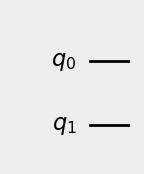

f2 (constant 1)


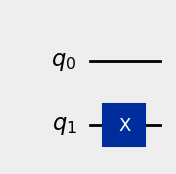

f3 (balanced: f(x)=x)


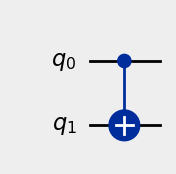

f4 (balanced: f(x)=1-x)


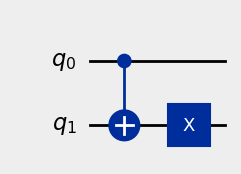

In [10]:
# Testing problem 3 oracles
from IPython.display import display

oracle1 = oracle_f1()
oracle2 = oracle_f2()
oracle3 = oracle_f3()
oracle4 = oracle_f4()

for name, qc in [("f1 (constant 0)", oracle1), ("f2 (constant 1)", oracle2),
                 ("f3 (balanced: f(x)=x)", oracle3), ("f4 (balanced: f(x)=1-x)", oracle4)]:
    print(name)
    display(qc.draw(output="mpl", style={"backgroundcolor": "#EEEEEE"}))

#pip install pylatexenc
#could change the draw method to qc.draw('mpl') but would need to check if I can install pylatexenc first
#This is also another way to do the representation using the circuit drawer - they look the same though so its not hugely important to change it.
#circuit_drawer(oracle1, output="mpl", style={"backgroundcolor": "#EEEEEE"})

### Explanation of Oracles in Problem
**The Deutsch Algorithm**

Though the name is similar the Deutsch Jozsa Algorithm it's actually different on a few fields. Both can determine if a given function f: {0,1}->{0,1} is constant (same output for both inputs) or balanced (different outputs for each input). The main difference is that the Deutsch algorithm accepts a single bit as an input and has the advantage of solving the problem with a single evaluation as opposed to multiple. It also uses 2 qubits, one for input and one for output as opposed to n+1 qubits

#### **Key Intuitions**
- Constant oracles affect both inputs the same way.
- Balanced oracles affect x = 0 and x=1 differently.
- That “difference” can be turned into measurable phase/interference as we demonstrate in problem 4

## **Problem 4 - Deutsch's Algorithm with Qiskit**

This problem is meant to demonstrate a solution to the Deutsch algorithm using Qiskit, which is a quantum computing framework. The goal is to implement the algorithm and test it with the oracles we created in Problem 3 to determine whether they are constant or balanced.

In [14]:
#Solution area for problem 4
def deutsch_algorithm(oracle):
    #Create a quantum circuit with 2 qubits and 1 classical bit
    qc = QuantumCircuit(2, 1)

    #Step 1: Initialize the first qubit to |0⟩ and the second qubit to |1⟩
    qc.x(1)  # Set the second qubit to |1⟩

    #Step 2: Apply Hadamard gates to both qubits
    qc.h(0)
    qc.h(1)

    #Step 3: Apply the oracle function
    qc.compose(oracle, inplace=True)

    #Step 4: Apply Hadamard gate to the first qubit again
    qc.h(0)

    #Step 5: Measure the first qubit
    qc.measure(0, 0)

    return qc

Circuit for oracle f1:


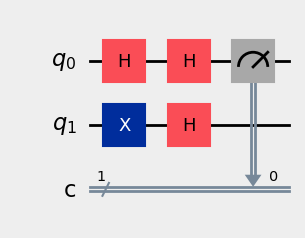

In [15]:
#Testing area
oracle1 = oracle_f1()
qc1 = deutsch_algorithm(oracle1)
print("Circuit for oracle f1:")
display(qc1.draw(output="mpl", style={"backgroundcolor": "#EEEEEE"}))

## **Problem 5- Scaling to the Deutsch–Jozsa Algorithm**

In [13]:
#Solution area for problem 5